# StreetLight Anomaly — v6 Supervised Gradient Boosting Benchmark

**4% — StreetLight Anomaly**

Dataset:

```text
/kaggle/input/datasets/loliwibu/lead-large-scale-energy-anomaly-detection
```

This notebook redesigns the project around a trustworthy supervised benchmark.

## What this notebook does

1. Uses only raw `train.csv` for the main benchmark.
2. Builds **causal** temporal features.
3. Evaluates two protocols:
   - **Temporal holdout** → forward-in-time behavior.
   - **Building-grouped holdout** → generalization to unseen buildings.
4. Compares:
   - robust-z rule
   - Isolation Forest
   - LightGBM classifier
5. Reports:
   - PR-AUC
   - ROC-AUC
   - precision / recall / F1
   - Precision@K / Recall@K / Lift@K
   - event recall
   - false alerts per building per week
6. Exports the best temporal LightGBM model for the portfolio app.

### Important framing

LEAD is a **building smart-meter benchmark**, not real street-light telemetry.

This project explores how energy-anomaly prioritization could support a future street-light monitoring workflow.

In [1]:
from pathlib import Path
import json
import random
import shutil
import time
import warnings
import zipfile

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import IsolationForest, HistGradientBoostingClassifier
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    precision_score,
    recall_score,
    f1_score,
    accuracy_score,
    confusion_matrix,
)
from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import RobustScaler

warnings.filterwarnings("ignore")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

ROOT = Path("/kaggle/input/datasets/loliwibu/lead-large-scale-energy-anomaly-detection")
TRAIN_PATH = ROOT / "train.csv"

WORK = Path("/kaggle/working/streetlight_anomaly_v6")
REPORTS = WORK / "reports"
MODELS = WORK / "models"
ASSETS = WORK / "assets"

if WORK.exists():
    shutil.rmtree(WORK)

for p in [REPORTS, MODELS, ASSETS]:
    p.mkdir(parents=True, exist_ok=True)

print("Dataset exists:", TRAIN_PATH.exists())
assert TRAIN_PATH.exists(), f"Dataset tidak ditemukan: {TRAIN_PATH}"

# Prefer LightGBM if Kaggle has it.
try:
    import lightgbm as lgb
    HAVE_LGBM = True
    print("LightGBM:", lgb.__version__)
except Exception as e:
    HAVE_LGBM = False
    print("LightGBM unavailable. Fallback to HistGradientBoostingClassifier.")
    print("Reason:", repr(e))

Dataset exists: True
LightGBM: 4.6.0


## 1. Load raw LEAD data

In [2]:
df = pd.read_csv(
    TRAIN_PATH,
    usecols=["building_id", "timestamp", "meter_reading", "anomaly"],
)

df["timestamp"] = pd.to_datetime(df["timestamp"], errors="coerce")
df["building_id"] = pd.to_numeric(df["building_id"], errors="coerce")
df["meter_reading"] = pd.to_numeric(df["meter_reading"], errors="coerce")
df["anomaly"] = pd.to_numeric(df["anomaly"], errors="coerce").fillna(0).astype("int8")

df = (
    df.dropna(subset=["building_id", "timestamp", "meter_reading"])
      .sort_values(["building_id", "timestamp"])
      .reset_index(drop=True)
)

df["building_id"] = df["building_id"].astype("int32")

print("Rows:", len(df))
print("Buildings:", df["building_id"].nunique())
print("Range:", df["timestamp"].min(), "->", df["timestamp"].max())
print("Anomaly rate:", f"{df['anomaly'].mean():.4%}")
display(df.head())

Rows: 1641841
Buildings: 200
Range: 2016-01-01 00:00:00 -> 2016-12-31 23:00:00
Anomaly rate: 2.2716%


,building_id,timestamp,meter_reading,anomaly
0,1,2016-05-20 18:00:00,27.688,0
1,1,2016-05-20 19:00:00,36.891,0
2,1,2016-05-20 20:00:00,37.051,0
3,1,2016-05-20 21:00:00,37.291,0
4,1,2016-05-20 22:00:00,38.651,0


## 2. Causal feature engineering

All temporal features use the current reading and/or **past-only** history.

For the deployable story, we avoid centered windows and future values.

In [3]:
def add_causal_features(frame):
    out = frame.copy()
    out = out.sort_values(["building_id", "timestamp"]).reset_index(drop=True)

    out["hour"] = out["timestamp"].dt.hour.astype("int8")
    out["dow"] = out["timestamp"].dt.dayofweek.astype("int8")
    out["month"] = out["timestamp"].dt.month.astype("int8")
    out["weekend"] = (out["dow"] >= 5).astype("int8")
    out["hour_of_week"] = (out["dow"] * 24 + out["hour"]).astype("int16")

    out["hour_sin"] = np.sin(2 * np.pi * out["hour"] / 24.0)
    out["hour_cos"] = np.cos(2 * np.pi * out["hour"] / 24.0)
    out["dow_sin"] = np.sin(2 * np.pi * out["dow"] / 7.0)
    out["dow_cos"] = np.cos(2 * np.pi * out["dow"] / 7.0)

    g = out.groupby("building_id", group_keys=False)

    for lag in [1, 2, 24, 168]:
        out[f"lag_{lag}"] = g["meter_reading"].shift(lag)

    # Past-only rolling features:
    shifted = g["meter_reading"].shift(1)

    out["rolling_mean_6"] = (
        shifted.groupby(out["building_id"])
               .rolling(6, min_periods=3)
               .mean()
               .reset_index(level=0, drop=True)
    )

    out["rolling_mean_24"] = (
        shifted.groupby(out["building_id"])
               .rolling(24, min_periods=8)
               .mean()
               .reset_index(level=0, drop=True)
    )

    out["rolling_std_24"] = (
        shifted.groupby(out["building_id"])
               .rolling(24, min_periods=8)
               .std()
               .reset_index(level=0, drop=True)
    )

    out["rolling_min_24"] = (
        shifted.groupby(out["building_id"])
               .rolling(24, min_periods=8)
               .min()
               .reset_index(level=0, drop=True)
    )

    out["rolling_max_24"] = (
        shifted.groupby(out["building_id"])
               .rolling(24, min_periods=8)
               .max()
               .reset_index(level=0, drop=True)
    )

    zero_flag = (out["meter_reading"] == 0).astype("float32")
    zero_shifted = zero_flag.groupby(out["building_id"]).shift(1)
    out["zero_count_24"] = (
        zero_shifted.groupby(out["building_id"])
                    .rolling(24, min_periods=8)
                    .sum()
                    .reset_index(level=0, drop=True)
    )

    # Current-vs-past differences.
    eps = 1.0
    out["diff_1"] = out["meter_reading"] - out["lag_1"]
    out["diff_24"] = out["meter_reading"] - out["lag_24"]
    out["diff_168"] = out["meter_reading"] - out["lag_168"]

    out["ratio_lag_1"] = out["meter_reading"] / (out["lag_1"].abs() + eps)
    out["ratio_lag_24"] = out["meter_reading"] / (out["lag_24"].abs() + eps)
    out["ratio_lag_168"] = out["meter_reading"] / (out["lag_168"].abs() + eps)

    # Flatline / constant behavior proxy.
    out["abs_diff_1"] = out["diff_1"].abs()
    flat_flag = (out["abs_diff_1"] < 1e-6).astype("float32")
    flat_shifted = flat_flag.groupby(out["building_id"]).shift(1)
    out["flat_count_24"] = (
        flat_shifted.groupby(out["building_id"])
                    .rolling(24, min_periods=8)
                    .sum()
                    .reset_index(level=0, drop=True)
    )

    out.replace([np.inf, -np.inf], np.nan, inplace=True)

    return out


feat = add_causal_features(df)

print("Rows after feature creation:", len(feat))
display(feat.head())

Rows after feature creation: 1641841


,building_id,timestamp,meter_reading,anomaly,hour,dow,month,weekend,hour_of_week,hour_sin,...,rolling_max_24,zero_count_24,diff_1,diff_24,diff_168,ratio_lag_1,ratio_lag_24,ratio_lag_168,abs_diff_1,flat_count_24
0,1,2016-05-20 18:00:00,27.688,0,18,4,5,0,114,-1.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,2016-05-20 19:00:00,36.891,0,19,4,5,0,115,-0.965926,...,NaN,NaN,9.203,NaN,NaN,1.285938,NaN,NaN,9.203,NaN
2,1,2016-05-20 20:00:00,37.051,0,20,4,5,0,116,-0.866025,...,NaN,NaN,0.160,NaN,NaN,0.977831,NaN,NaN,0.160,NaN
3,1,2016-05-20 21:00:00,37.291,0,21,4,5,0,117,-0.707107,...,NaN,NaN,0.240,NaN,NaN,0.980027,NaN,NaN,0.240,NaN
4,1,2016-05-20 22:00:00,38.651,0,22,4,5,0,118,-0.500000,...,NaN,NaN,1.360,NaN,NaN,1.009402,NaN,NaN,1.360,NaN


## 3. Helper functions

Baseline statistics are always fit **inside the training split** and then merged into validation/test.

This avoids full-year per-building normalization leakage.

In [4]:
def fit_baseline_tables(train_frame):
    # Use normal training rows only for the anomaly reference.
    normal = train_frame[train_frame["anomaly"] == 0].copy()

    how_median = (
        normal.groupby(["building_id", "hour_of_week"])["meter_reading"]
              .median()
              .rename("baseline_median")
              .reset_index()
    )

    tmp = normal.merge(
        how_median,
        on=["building_id", "hour_of_week"],
        how="left",
    )
    tmp["abs_dev"] = (tmp["meter_reading"] - tmp["baseline_median"]).abs()

    how_mad = (
        tmp.groupby(["building_id", "hour_of_week"])["abs_dev"]
           .median()
           .rename("baseline_mad")
           .reset_index()
    )

    baseline = how_median.merge(
        how_mad,
        on=["building_id", "hour_of_week"],
        how="left",
    )

    # Fallback for unseen buildings.
    global_how_median = (
        normal.groupby("hour_of_week")["meter_reading"]
              .median()
              .rename("global_how_median")
              .reset_index()
    )

    global_median = float(normal["meter_reading"].median())

    valid_mads = baseline.loc[baseline["baseline_mad"] > 0, "baseline_mad"]
    global_mad = float(valid_mads.median()) if len(valid_mads) else 1.0

    building_median = (
        normal.groupby("building_id")["meter_reading"]
              .median()
              .rename("building_median")
              .reset_index()
    )

    return {
        "baseline": baseline,
        "global_how_median": global_how_median,
        "building_median": building_median,
        "global_median": global_median,
        "global_mad": global_mad,
    }


def apply_baseline_features(frame, tables):
    out = frame.copy()

    out = out.merge(
        tables["baseline"],
        on=["building_id", "hour_of_week"],
        how="left",
    )

    out = out.merge(
        tables["global_how_median"],
        on="hour_of_week",
        how="left",
    )

    out = out.merge(
        tables["building_median"],
        on="building_id",
        how="left",
    )

    out["baseline_median"] = (
        out["baseline_median"]
        .fillna(out["global_how_median"])
        .fillna(out["building_median"])
        .fillna(tables["global_median"])
    )

    out["baseline_mad"] = (
        out["baseline_mad"]
        .where(out["baseline_mad"] > 0)
        .fillna(tables["global_mad"])
    )

    eps = 1.0
    out["robust_z"] = (
        0.6745
        * (out["meter_reading"] - out["baseline_median"])
        / (out["baseline_mad"] + eps)
    )

    out["relative_to_baseline"] = (
        (out["meter_reading"] - out["baseline_median"])
        / (out["baseline_median"].abs() + eps)
    )

    out["relative_to_building_scale"] = (
        out["meter_reading"]
        / (out["building_median"].abs().fillna(tables["global_median"]) + eps)
    )

    # Stable clipping.
    for c, limit in {
        "robust_z": 30.0,
        "relative_to_baseline": 15.0,
        "relative_to_building_scale": 20.0,
        "ratio_lag_1": 20.0,
        "ratio_lag_24": 20.0,
        "ratio_lag_168": 20.0,
    }.items():
        if c in out.columns:
            out[c] = out[c].clip(-limit, limit)

    out.replace([np.inf, -np.inf], np.nan, inplace=True)

    return out


BASE_FEATURES = [
    "meter_reading",
    "hour",
    "dow",
    "month",
    "weekend",
    "hour_sin",
    "hour_cos",
    "dow_sin",
    "dow_cos",
    "lag_1",
    "lag_2",
    "lag_24",
    "lag_168",
    "rolling_mean_6",
    "rolling_mean_24",
    "rolling_std_24",
    "rolling_min_24",
    "rolling_max_24",
    "zero_count_24",
    "flat_count_24",
    "diff_1",
    "diff_24",
    "diff_168",
    "ratio_lag_1",
    "ratio_lag_24",
    "ratio_lag_168",
    "baseline_median",
    "baseline_mad",
    "robust_z",
    "relative_to_baseline",
    "relative_to_building_scale",
]

def drop_unscorable(frame, feature_cols):
    out = frame.copy()
    out = out.dropna(subset=feature_cols + ["anomaly"]).reset_index(drop=True)
    return out

## 4. Metrics

In [5]:
def safe_roc_auc(y_true, scores):
    return (
        float(roc_auc_score(y_true, scores))
        if np.unique(y_true).size > 1
        else np.nan
    )

def safe_pr_auc(y_true, scores):
    return (
        float(average_precision_score(y_true, scores))
        if np.unique(y_true).size > 1
        else np.nan
    )

def choose_threshold_by_f2(y_true, scores):
    # Validation-only threshold selection.
    percentiles = np.concatenate([
        np.arange(70.0, 99.0, 0.5),
        np.arange(99.0, 99.91, 0.1),
    ])

    rows = []
    beta = 2.0

    for p in percentiles:
        t = float(np.percentile(scores, p))
        pred = (scores >= t).astype("int8")

        precision = precision_score(y_true, pred, zero_division=0)
        recall = recall_score(y_true, pred, zero_division=0)

        denom = beta**2 * precision + recall
        f2 = (
            (1 + beta**2) * precision * recall / denom
            if denom > 0 else 0.0
        )

        rows.append({
            "percentile": p,
            "threshold": t,
            "precision": precision,
            "recall": recall,
            "f1": f1_score(y_true, pred, zero_division=0),
            "f2": f2,
            "predicted_rate": pred.mean(),
        })

    table = (
        pd.DataFrame(rows)
        .sort_values(["f2", "recall", "precision"], ascending=False)
        .reset_index(drop=True)
    )

    return float(table.iloc[0]["threshold"]), table


def point_metrics(y_true, scores, threshold):
    pred = (scores >= threshold).astype("int8")

    return {
        "rows": int(len(y_true)),
        "base_rate": float(np.mean(y_true)),
        "predicted_rate": float(np.mean(pred)),
        "accuracy": float(accuracy_score(y_true, pred)),
        "precision": float(precision_score(y_true, pred, zero_division=0)),
        "recall": float(recall_score(y_true, pred, zero_division=0)),
        "f1": float(f1_score(y_true, pred, zero_division=0)),
        "roc_auc": safe_roc_auc(y_true, scores),
        "pr_auc": safe_pr_auc(y_true, scores),
        "threshold": float(threshold),
    }


def top_k_metrics(y_true, scores, fractions=(0.005, 0.01, 0.02, 0.05, 0.10)):
    y_true = np.asarray(y_true)
    scores = np.asarray(scores)

    base_rate = y_true.mean()
    total_anomalies = y_true.sum()
    order = np.argsort(-scores)

    rows = []

    for fraction in fractions:
        k = max(1, int(len(y_true) * fraction))
        selected = order[:k]

        hits = int(y_true[selected].sum())
        precision_k = hits / k
        recall_k = hits / total_anomalies if total_anomalies else 0.0
        lift = precision_k / base_rate if base_rate > 0 else 0.0

        rows.append({
            "top_fraction": fraction,
            "k": k,
            "hits": hits,
            "precision_at_k": precision_k,
            "recall_at_k": recall_k,
            "lift_vs_random": lift,
        })

    return pd.DataFrame(rows)


def add_event_ids(frame):
    out = frame.sort_values(["building_id", "timestamp"]).copy()

    # New event whenever anomaly starts or time gap > 1 hour.
    prev_anom = out.groupby("building_id")["anomaly"].shift(1).fillna(0)
    prev_time = out.groupby("building_id")["timestamp"].shift(1)
    gap_hours = (
        (out["timestamp"] - prev_time)
        .dt.total_seconds()
        .div(3600)
    )

    event_start = (
        (out["anomaly"] == 1)
        & (
            (prev_anom != 1)
            | (gap_hours != 1)
        )
    )

    out["event_counter"] = (
        event_start.groupby(out["building_id"]).cumsum()
    )

    out["event_id"] = np.where(
        out["anomaly"] == 1,
        out["building_id"].astype(str)
        + "_"
        + out["event_counter"].astype(int).astype(str),
        None,
    )

    return out


def event_and_alert_metrics(frame, scores, threshold):
    out = frame[["building_id", "timestamp", "anomaly"]].copy()
    out["score"] = scores
    out["pred"] = (scores >= threshold).astype("int8")
    out = add_event_ids(out)

    anomaly_rows = out[out["anomaly"] == 1].copy()

    if len(anomaly_rows):
        event_hits = (
            anomaly_rows
            .groupby("event_id")["pred"]
            .max()
        )
        event_recall = float(event_hits.mean())
        total_events = int(len(event_hits))
        detected_events = int(event_hits.sum())
    else:
        event_recall = np.nan
        total_events = 0
        detected_events = 0

    false_alerts = int(
        ((out["pred"] == 1) & (out["anomaly"] == 0)).sum()
    )

    span_days = max(
        1.0,
        (out["timestamp"].max() - out["timestamp"].min()).total_seconds() / 86400.0,
    )
    building_weeks = out["building_id"].nunique() * span_days / 7.0

    false_alerts_per_building_week = (
        false_alerts / building_weeks
        if building_weeks > 0
        else np.nan
    )

    return {
        "total_events": total_events,
        "detected_events": detected_events,
        "event_recall": event_recall,
        "false_alert_points": false_alerts,
        "false_alerts_per_building_week": float(false_alerts_per_building_week),
    }

# PART A — Temporal Holdout

Question:

> Can the model detect anomalies in future time periods on buildings already observed in training?

In [6]:
# Global time split with a one-week purge gap before validation and test.

times = np.sort(feat["timestamp"].dropna().unique())

train_cut = pd.Timestamp(times[int(len(times) * 0.70)])
val_cut = pd.Timestamp(times[int(len(times) * 0.85)])
PURGE = pd.Timedelta(days=7)

temporal_train = feat[feat["timestamp"] < (train_cut - PURGE)].copy()
temporal_val = feat[
    (feat["timestamp"] >= train_cut)
    & (feat["timestamp"] < (val_cut - PURGE))
].copy()
temporal_test = feat[feat["timestamp"] >= val_cut].copy()

print("Temporal train:", temporal_train["timestamp"].min(), "->", temporal_train["timestamp"].max(), len(temporal_train))
print("Temporal val  :", temporal_val["timestamp"].min(), "->", temporal_val["timestamp"].max(), len(temporal_val))
print("Temporal test :", temporal_test["timestamp"].min(), "->", temporal_test["timestamp"].max(), len(temporal_test))

baseline_t = fit_baseline_tables(temporal_train)

temporal_train = apply_baseline_features(temporal_train, baseline_t)
temporal_val = apply_baseline_features(temporal_val, baseline_t)
temporal_test = apply_baseline_features(temporal_test, baseline_t)

temporal_train = drop_unscorable(temporal_train, BASE_FEATURES)
temporal_val = drop_unscorable(temporal_val, BASE_FEATURES)
temporal_test = drop_unscorable(temporal_test, BASE_FEATURES)

for name, frame in [
    ("train", temporal_train),
    ("val", temporal_val),
    ("test", temporal_test),
]:
    print(name, len(frame), "base rate:", f"{frame['anomaly'].mean():.4%}")

Temporal train: 2016-01-01 00:00:00 -> 2016-09-06 03:00:00 1107384
Temporal val  : 2016-09-13 04:00:00 -> 2016-10-31 01:00:00 212128
Temporal test : 2016-11-07 02:00:00 -> 2016-12-31 23:00:00 256913
train 1073784 base rate: 2.4526%
val 212128 base rate: 2.0756%
test 256913 base rate: 2.0201%


## A1. Robust-z baseline

In [7]:
# Score higher = more anomalous.
rz_val_scores = temporal_val["robust_z"].abs().to_numpy()
rz_test_scores = temporal_test["robust_z"].abs().to_numpy()

rz_threshold, rz_threshold_table = choose_threshold_by_f2(
    temporal_val["anomaly"].to_numpy(),
    rz_val_scores,
)

rz_metrics = point_metrics(
    temporal_test["anomaly"].to_numpy(),
    rz_test_scores,
    rz_threshold,
)

print(json.dumps(rz_metrics, indent=2))

rz_topk = top_k_metrics(
    temporal_test["anomaly"].to_numpy(),
    rz_test_scores,
)

rz_event = event_and_alert_metrics(
    temporal_test,
    rz_test_scores,
    rz_threshold,
)

display(rz_topk)
print(rz_event)

{
  "rows": 256913,
  "base_rate": 0.02020139113240669,
  "predicted_rate": 0.08610307769556232,
  "accuracy": 0.9113201745337915,
  "precision": 0.10234618688124407,
  "recall": 0.43622350674373794,
  "f1": 0.1657940024166087,
  "roc_auc": 0.7467868973049305,
  "pr_auc": 0.08308529885186475,
  "threshold": 3.751419120246222
}


,top_fraction,k,hits,precision_at_k,recall_at_k,lift_vs_random
0,0.005,1284,89,0.069315,0.017148,3.431182
1,0.010,2569,280,0.108992,0.053950,5.395263
2,0.020,5138,773,0.150448,0.148940,7.447390
3,0.050,12845,1650,0.128455,0.317919,6.358703
4,0.100,25691,2463,0.095870,0.474566,4.745720


{'total_events': 650, 'detected_events': 274, 'event_recall': 0.42153846153846153, 'false_alert_points': 19857, 'false_alerts_per_building_week': 12.728700449857488}


## A2. Isolation Forest baseline

In [8]:
IF_FEATURES = [
    "robust_z",
    "relative_to_baseline",
    "relative_to_building_scale",
    "diff_1",
    "diff_24",
    "diff_168",
    "rolling_mean_24",
    "rolling_std_24",
    "zero_count_24",
    "flat_count_24",
    "hour_sin",
    "hour_cos",
    "dow_sin",
    "dow_cos",
]

if_train_normal = temporal_train[
    temporal_train["anomaly"] == 0
].copy()

MAX_IF_FIT = 250_000

if len(if_train_normal) > MAX_IF_FIT:
    idx = np.linspace(0, len(if_train_normal) - 1, MAX_IF_FIT, dtype=int)
    if_fit_frame = if_train_normal.iloc[idx].copy()
else:
    if_fit_frame = if_train_normal.copy()

if_scaler = RobustScaler()
X_if_fit = if_scaler.fit_transform(if_fit_frame[IF_FEATURES].astype("float32"))

if_model = IsolationForest(
    n_estimators=300,
    max_samples=4096,
    contamination="auto",
    max_features=0.9,
    random_state=SEED,
    n_jobs=-1,
)

if_model.fit(X_if_fit)

def if_score(frame):
    X = if_scaler.transform(frame[IF_FEATURES].astype("float32"))
    return -if_model.score_samples(X)

if_val_scores = if_score(temporal_val)
if_test_scores = if_score(temporal_test)

if_threshold, if_threshold_table = choose_threshold_by_f2(
    temporal_val["anomaly"].to_numpy(),
    if_val_scores,
)

if_metrics = point_metrics(
    temporal_test["anomaly"].to_numpy(),
    if_test_scores,
    if_threshold,
)

print(json.dumps(if_metrics, indent=2))

if_topk = top_k_metrics(
    temporal_test["anomaly"].to_numpy(),
    if_test_scores,
)

if_event = event_and_alert_metrics(
    temporal_test,
    if_test_scores,
    if_threshold,
)

display(if_topk)
print(if_event)

{
  "rows": 256913,
  "base_rate": 0.02020139113240669,
  "predicted_rate": 0.06022661367856045,
  "accuracy": 0.9422878562003479,
  "precision": 0.18858657015446262,
  "recall": 0.5622350674373796,
  "f1": 0.28243720660117116,
  "roc_auc": 0.8401490296889254,
  "pr_auc": 0.14473201065439928,
  "threshold": 0.469727044098019
}


,top_fraction,k,hits,precision_at_k,recall_at_k,lift_vs_random
0,0.005,1284,173,0.134735,0.033333,6.669600
1,0.010,2569,412,0.160374,0.079383,7.938745
2,0.020,5138,977,0.190152,0.188247,9.412808
3,0.050,12845,2632,0.204905,0.507129,10.143095
4,0.100,25691,3488,0.135767,0.672062,6.720695


{'total_events': 650, 'detected_events': 300, 'event_recall': 0.46153846153846156, 'false_alert_points': 12555, 'false_alerts_per_building_week': 8.047984798708805}


## A3. LightGBM classifier

`scale_pos_weight` is initialized around sqrt(negative / positive), then kept moderate.

In [9]:
MODEL_FEATURES = BASE_FEATURES.copy()

X_train = temporal_train[MODEL_FEATURES].astype("float32")
y_train = temporal_train["anomaly"].astype("int8")

X_val = temporal_val[MODEL_FEATURES].astype("float32")
y_val = temporal_val["anomaly"].astype("int8")

X_test = temporal_test[MODEL_FEATURES].astype("float32")
y_test = temporal_test["anomaly"].astype("int8")

neg = int((y_train == 0).sum())
pos = int((y_train == 1).sum())
scale_pos_weight = float(np.sqrt(neg / max(pos, 1)))

print("neg:", neg, "pos:", pos, "scale_pos_weight:", scale_pos_weight)

if HAVE_LGBM:
    clf = lgb.LGBMClassifier(
        objective="binary",
        n_estimators=1200,
        learning_rate=0.03,
        num_leaves=31,
        max_depth=-1,
        min_child_samples=50,
        subsample=0.85,
        colsample_bytree=0.85,
        reg_alpha=0.2,
        reg_lambda=0.5,
        scale_pos_weight=scale_pos_weight,
        random_state=SEED,
        n_jobs=-1,
        verbosity=-1,
    )

    clf.fit(
        X_train,
        y_train,
        eval_set=[(X_val, y_val)],
        eval_metric="average_precision",
        callbacks=[
            lgb.early_stopping(100, verbose=False),
            lgb.log_evaluation(period=100),
        ],
    )

    lgb_val_scores = clf.predict_proba(X_val)[:, 1]
    lgb_test_scores = clf.predict_proba(X_test)[:, 1]

else:
    # Fallback if LightGBM is not available.
    clf = HistGradientBoostingClassifier(
        learning_rate=0.05,
        max_iter=500,
        max_leaf_nodes=31,
        min_samples_leaf=50,
        l2_regularization=0.5,
        random_state=SEED,
    )

    # HistGradientBoosting does not expose scale_pos_weight.
    # Use sample weights instead.
    sample_weight = np.where(
        y_train.to_numpy() == 1,
        scale_pos_weight,
        1.0,
    )

    clf.fit(
        X_train,
        y_train,
        sample_weight=sample_weight,
    )

    lgb_val_scores = clf.predict_proba(X_val)[:, 1]
    lgb_test_scores = clf.predict_proba(X_test)[:, 1]

lgb_threshold, lgb_threshold_table = choose_threshold_by_f2(
    y_val.to_numpy(),
    lgb_val_scores,
)

lgb_metrics = point_metrics(
    y_test.to_numpy(),
    lgb_test_scores,
    lgb_threshold,
)

print(json.dumps(lgb_metrics, indent=2))

lgb_topk = top_k_metrics(
    y_test.to_numpy(),
    lgb_test_scores,
)

lgb_event = event_and_alert_metrics(
    temporal_test,
    lgb_test_scores,
    lgb_threshold,
)

display(lgb_topk)
print(lgb_event)

neg: 1047448 pos: 26336 scale_pos_weight: 6.306542534252068
[100]	valid_0's average_precision: 0.715163	valid_0's binary_logloss: 0.0710575
[200]	valid_0's average_precision: 0.727159	valid_0's binary_logloss: 0.0676981
[300]	valid_0's average_precision: 0.731645	valid_0's binary_logloss: 0.0648932
[400]	valid_0's average_precision: 0.73199	valid_0's binary_logloss: 0.0626769
{
  "rows": 256913,
  "base_rate": 0.02020139113240669,
  "predicted_rate": 0.02520697668082191,
  "accuracy": 0.9807794856624616,
  "precision": 0.5194564546016059,
  "recall": 0.648169556840077,
  "f1": 0.576718669638265,
  "roc_auc": 0.9089942321757369,
  "pr_auc": 0.6692787958372081,
  "threshold": 0.4295065964802488
}


,top_fraction,k,hits,precision_at_k,recall_at_k,lift_vs_random
0,0.005,1284,1284,1.000000,0.247399,49.501541
1,0.010,2569,2499,0.972752,0.481503,48.152726
2,0.020,5138,3256,0.633710,0.627360,31.369603
3,0.050,12845,3664,0.285247,0.705973,14.120175
4,0.100,25691,3977,0.154801,0.766281,7.662903


{'total_events': 650, 'detected_events': 331, 'event_recall': 0.5092307692307693, 'false_alert_points': 3112, 'false_alerts_per_building_week': 1.9948489600622703}


## A4. Optional IF score as supervised feature

In [10]:
# Fit IF only on temporal training split, then append the score.
temporal_train_if = temporal_train.copy()
temporal_val_if = temporal_val.copy()
temporal_test_if = temporal_test.copy()

temporal_train_if["if_score"] = if_score(temporal_train_if)
temporal_val_if["if_score"] = if_score(temporal_val_if)
temporal_test_if["if_score"] = if_score(temporal_test_if)

MODEL_FEATURES_IF = MODEL_FEATURES + ["if_score"]

X_train_if = temporal_train_if[MODEL_FEATURES_IF].astype("float32")
X_val_if = temporal_val_if[MODEL_FEATURES_IF].astype("float32")
X_test_if = temporal_test_if[MODEL_FEATURES_IF].astype("float32")

if HAVE_LGBM:
    clf_if = lgb.LGBMClassifier(
        objective="binary",
        n_estimators=1200,
        learning_rate=0.03,
        num_leaves=31,
        min_child_samples=50,
        subsample=0.85,
        colsample_bytree=0.85,
        reg_alpha=0.2,
        reg_lambda=0.5,
        scale_pos_weight=scale_pos_weight,
        random_state=SEED,
        n_jobs=-1,
        verbosity=-1,
    )

    clf_if.fit(
        X_train_if,
        y_train,
        eval_set=[(X_val_if, y_val)],
        eval_metric="average_precision",
        callbacks=[
            lgb.early_stopping(100, verbose=False),
            lgb.log_evaluation(period=100),
        ],
    )

    lgb_if_val_scores = clf_if.predict_proba(X_val_if)[:, 1]
    lgb_if_test_scores = clf_if.predict_proba(X_test_if)[:, 1]

else:
    clf_if = HistGradientBoostingClassifier(
        learning_rate=0.05,
        max_iter=500,
        max_leaf_nodes=31,
        min_samples_leaf=50,
        l2_regularization=0.5,
        random_state=SEED,
    )

    clf_if.fit(
        X_train_if,
        y_train,
        sample_weight=sample_weight,
    )

    lgb_if_val_scores = clf_if.predict_proba(X_val_if)[:, 1]
    lgb_if_test_scores = clf_if.predict_proba(X_test_if)[:, 1]

lgb_if_threshold, lgb_if_threshold_table = choose_threshold_by_f2(
    y_val.to_numpy(),
    lgb_if_val_scores,
)

lgb_if_metrics = point_metrics(
    y_test.to_numpy(),
    lgb_if_test_scores,
    lgb_if_threshold,
)

lgb_if_topk = top_k_metrics(
    y_test.to_numpy(),
    lgb_if_test_scores,
)

lgb_if_event = event_and_alert_metrics(
    temporal_test,
    lgb_if_test_scores,
    lgb_if_threshold,
)

print(json.dumps(lgb_if_metrics, indent=2))
display(lgb_if_topk)
print(lgb_if_event)

[100]	valid_0's average_precision: 0.716259	valid_0's binary_logloss: 0.070674
[200]	valid_0's average_precision: 0.72972	valid_0's binary_logloss: 0.0671772
[300]	valid_0's average_precision: 0.734681	valid_0's binary_logloss: 0.0644324
[400]	valid_0's average_precision: 0.735208	valid_0's binary_logloss: 0.0626039
[500]	valid_0's average_precision: 0.73603	valid_0's binary_logloss: 0.061056
[600]	valid_0's average_precision: 0.735853	valid_0's binary_logloss: 0.0594603
{
  "rows": 256913,
  "base_rate": 0.02020139113240669,
  "predicted_rate": 0.02588814112170268,
  "accuracy": 0.9800749670121792,
  "precision": 0.5053375432265824,
  "recall": 0.6475915221579961,
  "f1": 0.567688539819272,
  "roc_auc": 0.9062490395194394,
  "pr_auc": 0.667473093874665,
  "threshold": 0.4106362430421004
}


,top_fraction,k,hits,precision_at_k,recall_at_k,lift_vs_random
0,0.005,1284,1284,1.000000,0.247399,49.501541
1,0.010,2569,2498,0.972363,0.481310,48.133457
2,0.020,5138,3202,0.623200,0.616956,30.849345
3,0.050,12845,3688,0.287116,0.710597,14.212665
4,0.100,25691,3983,0.155035,0.767437,7.674463


{'total_events': 650, 'detected_events': 335, 'event_recall': 0.5153846153846153, 'false_alert_points': 3290, 'false_alerts_per_building_week': 2.108950218060691}


## A5. Temporal benchmark table

In [11]:
temporal_comparison = pd.DataFrame([
    {"model": "RobustZ", **rz_metrics, **rz_event},
    {"model": "IsolationForest", **if_metrics, **if_event},
    {"model": "GradientBoosting", **lgb_metrics, **lgb_event},
    {"model": "GradientBoosting+IF", **lgb_if_metrics, **lgb_if_event},
])

display(
    temporal_comparison[
        [
            "model",
            "base_rate",
            "precision",
            "recall",
            "f1",
            "pr_auc",
            "roc_auc",
            "event_recall",
            "false_alerts_per_building_week",
        ]
    ]
)

temporal_comparison.to_csv(
    REPORTS / "temporal_model_comparison.csv",
    index=False,
)

topk_temporal = []
for model_name, table in [
    ("RobustZ", rz_topk),
    ("IsolationForest", if_topk),
    ("GradientBoosting", lgb_topk),
    ("GradientBoosting+IF", lgb_if_topk),
]:
    temp = table.copy()
    temp.insert(0, "model", model_name)
    topk_temporal.append(temp)

topk_temporal = pd.concat(topk_temporal, ignore_index=True)
display(topk_temporal)
topk_temporal.to_csv(REPORTS / "temporal_topk_comparison.csv", index=False)

,model,base_rate,precision,recall,f1,pr_auc,roc_auc,event_recall,false_alerts_per_building_week
0,RobustZ,0.020201,0.102346,0.436224,0.165794,0.083085,0.746787,0.421538,12.728700
1,IsolationForest,0.020201,0.188587,0.562235,0.282437,0.144732,0.840149,0.461538,8.047985
2,GradientBoosting,0.020201,0.519456,0.648170,0.576719,0.669279,0.908994,0.509231,1.994849
3,GradientBoosting+IF,0.020201,0.505338,0.647592,0.567689,0.667473,0.906249,0.515385,2.108950


,model,top_fraction,k,hits,precision_at_k,recall_at_k,lift_vs_random
0,RobustZ,0.005,1284,89,0.069315,0.017148,3.431182
1,RobustZ,0.010,2569,280,0.108992,0.053950,5.395263
2,RobustZ,0.020,5138,773,0.150448,0.148940,7.447390
3,RobustZ,0.050,12845,1650,0.128455,0.317919,6.358703
4,RobustZ,0.100,25691,2463,0.095870,0.474566,4.745720
5,IsolationForest,0.005,1284,173,0.134735,0.033333,6.669600
6,IsolationForest,0.010,2569,412,0.160374,0.079383,7.938745
7,IsolationForest,0.020,5138,977,0.190152,0.188247,9.412808
8,IsolationForest,0.050,12845,2632,0.204905,0.507129,10.143095
9,IsolationForest,0.100,25691,3488,0.135767,0.672062,6.720695


# PART B — Building-Grouped Holdout

Question:

> Can the model generalize to buildings never seen during training?

Important: building-specific baseline values are unavailable for unseen buildings, so the pipeline falls back to **training-derived global hour-of-week statistics**.

In [12]:
buildings = np.array(sorted(feat["building_id"].unique()))

# 70% train buildings, 15% validation, 15% test.
gss1 = GroupShuffleSplit(
    n_splits=1,
    train_size=0.70,
    random_state=SEED,
)

train_idx, temp_idx = next(
    gss1.split(
        buildings.reshape(-1, 1),
        groups=buildings,
    )
)

train_buildings = buildings[train_idx]
temp_buildings = buildings[temp_idx]

gss2 = GroupShuffleSplit(
    n_splits=1,
    train_size=0.50,
    random_state=SEED + 1,
)

val_idx2, test_idx2 = next(
    gss2.split(
        temp_buildings.reshape(-1, 1),
        groups=temp_buildings,
    )
)

val_buildings = temp_buildings[val_idx2]
test_buildings = temp_buildings[test_idx2]

group_train = feat[feat["building_id"].isin(train_buildings)].copy()
group_val = feat[feat["building_id"].isin(val_buildings)].copy()
group_test = feat[feat["building_id"].isin(test_buildings)].copy()

print("Buildings:", len(train_buildings), len(val_buildings), len(test_buildings))
print("Overlap train/val:", len(set(train_buildings) & set(val_buildings)))
print("Overlap train/test:", len(set(train_buildings) & set(test_buildings)))
print("Overlap val/test:", len(set(val_buildings) & set(test_buildings)))

baseline_g = fit_baseline_tables(group_train)

group_train = apply_baseline_features(group_train, baseline_g)
group_val = apply_baseline_features(group_val, baseline_g)
group_test = apply_baseline_features(group_test, baseline_g)

group_train = drop_unscorable(group_train, BASE_FEATURES)
group_val = drop_unscorable(group_val, BASE_FEATURES)
group_test = drop_unscorable(group_test, BASE_FEATURES)

for name, frame in [
    ("group_train", group_train),
    ("group_val", group_val),
    ("group_test", group_test),
]:
    print(name, len(frame), "buildings:", frame["building_id"].nunique(), "base rate:", f"{frame['anomaly'].mean():.4%}")

Buildings: 140 30 30
Overlap train/val: 0
Overlap train/test: 0
Overlap val/test: 0
group_train 1116413 buildings: 140 base rate: 2.2238%
group_val 244141 buildings: 30 base rate: 2.6132%
group_test 247687 buildings: 30 base rate: 2.2016%


## B1. Grouped Robust-z

In [13]:
grz_val_scores = group_val["robust_z"].abs().to_numpy()
grz_test_scores = group_test["robust_z"].abs().to_numpy()

grz_threshold, _ = choose_threshold_by_f2(
    group_val["anomaly"].to_numpy(),
    grz_val_scores,
)

grz_metrics = point_metrics(
    group_test["anomaly"].to_numpy(),
    grz_test_scores,
    grz_threshold,
)

grz_topk = top_k_metrics(
    group_test["anomaly"].to_numpy(),
    grz_test_scores,
)

grz_event = event_and_alert_metrics(
    group_test,
    grz_test_scores,
    grz_threshold,
)

print(json.dumps(grz_metrics, indent=2))
print(grz_event)
display(grz_topk)

{
  "rows": 247687,
  "base_rate": 0.022015689156071976,
  "predicted_rate": 0.03392588226269445,
  "accuracy": 0.944930496957854,
  "precision": 0.01285255265976437,
  "recall": 0.019805611589950485,
  "f1": 0.01558891454965358,
  "roc_auc": 0.6650003317202936,
  "pr_auc": 0.032410591110945804,
  "threshold": 30.0
}
{'total_events': 848, 'detected_events': 37, 'event_recall': 0.04363207547169811, 'false_alert_points': 8295, 'false_alerts_per_building_week': 5.391990713871155}


,top_fraction,k,hits,precision_at_k,recall_at_k,lift_vs_random
0,0.005,1238,11,0.008885,0.002017,0.403589
1,0.010,2476,26,0.010501,0.004768,0.476969
2,0.020,4953,99,0.019988,0.018155,0.907893
3,0.050,12384,133,0.010740,0.024390,0.487819
4,0.100,24768,207,0.008358,0.037961,0.379618


## B2. Grouped Isolation Forest

In [14]:
group_if_normal = group_train[group_train["anomaly"] == 0].copy()

if len(group_if_normal) > MAX_IF_FIT:
    idx = np.linspace(0, len(group_if_normal) - 1, MAX_IF_FIT, dtype=int)
    group_if_fit = group_if_normal.iloc[idx].copy()
else:
    group_if_fit = group_if_normal.copy()

group_if_scaler = RobustScaler()
X_group_if_fit = group_if_scaler.fit_transform(
    group_if_fit[IF_FEATURES].astype("float32")
)

group_if_model = IsolationForest(
    n_estimators=300,
    max_samples=4096,
    contamination="auto",
    max_features=0.9,
    random_state=SEED,
    n_jobs=-1,
)

group_if_model.fit(X_group_if_fit)

def group_if_score(frame):
    X = group_if_scaler.transform(frame[IF_FEATURES].astype("float32"))
    return -group_if_model.score_samples(X)

gif_val_scores = group_if_score(group_val)
gif_test_scores = group_if_score(group_test)

gif_threshold, _ = choose_threshold_by_f2(
    group_val["anomaly"].to_numpy(),
    gif_val_scores,
)

gif_metrics = point_metrics(
    group_test["anomaly"].to_numpy(),
    gif_test_scores,
    gif_threshold,
)

gif_topk = top_k_metrics(
    group_test["anomaly"].to_numpy(),
    gif_test_scores,
)

gif_event = event_and_alert_metrics(
    group_test,
    gif_test_scores,
    gif_threshold,
)

print(json.dumps(gif_metrics, indent=2))
print(gif_event)
display(gif_topk)

{
  "rows": 247687,
  "base_rate": 0.022015689156071976,
  "predicted_rate": 0.04226301743733018,
  "accuracy": 0.9451767755271775,
  "precision": 0.11186473060756591,
  "recall": 0.21474417751696315,
  "f1": 0.14710131273161234,
  "roc_auc": 0.7970386083948111,
  "pr_auc": 0.08101277501001676,
  "threshold": 0.5705960920526313
}
{'total_events': 848, 'detected_events': 174, 'event_recall': 0.20518867924528303, 'false_alert_points': 9297, 'false_alerts_per_building_week': 6.0433197910621015}


,top_fraction,k,hits,precision_at_k,recall_at_k,lift_vs_random
0,0.005,1238,83,0.067044,0.015221,3.045266
1,0.010,2476,91,0.036753,0.016688,1.669393
2,0.020,4953,104,0.020997,0.019072,0.953746
3,0.050,12384,1652,0.133398,0.302953,6.059221
4,0.100,24768,2678,0.108123,0.491106,4.911197


## B3. Grouped LightGBM

In [15]:
Xg_train = group_train[MODEL_FEATURES].astype("float32")
yg_train = group_train["anomaly"].astype("int8")

Xg_val = group_val[MODEL_FEATURES].astype("float32")
yg_val = group_val["anomaly"].astype("int8")

Xg_test = group_test[MODEL_FEATURES].astype("float32")
yg_test = group_test["anomaly"].astype("int8")

neg_g = int((yg_train == 0).sum())
pos_g = int((yg_train == 1).sum())
spw_g = float(np.sqrt(neg_g / max(pos_g, 1)))

if HAVE_LGBM:
    group_clf = lgb.LGBMClassifier(
        objective="binary",
        n_estimators=1200,
        learning_rate=0.03,
        num_leaves=31,
        min_child_samples=50,
        subsample=0.85,
        colsample_bytree=0.85,
        reg_alpha=0.2,
        reg_lambda=0.5,
        scale_pos_weight=spw_g,
        random_state=SEED,
        n_jobs=-1,
        verbosity=-1,
    )

    group_clf.fit(
        Xg_train,
        yg_train,
        eval_set=[(Xg_val, yg_val)],
        eval_metric="average_precision",
        callbacks=[
            lgb.early_stopping(100, verbose=False),
            lgb.log_evaluation(period=100),
        ],
    )

    glgb_val_scores = group_clf.predict_proba(Xg_val)[:, 1]
    glgb_test_scores = group_clf.predict_proba(Xg_test)[:, 1]

else:
    group_clf = HistGradientBoostingClassifier(
        learning_rate=0.05,
        max_iter=500,
        max_leaf_nodes=31,
        min_samples_leaf=50,
        l2_regularization=0.5,
        random_state=SEED,
    )

    sw_g = np.where(
        yg_train.to_numpy() == 1,
        spw_g,
        1.0,
    )

    group_clf.fit(
        Xg_train,
        yg_train,
        sample_weight=sw_g,
    )

    glgb_val_scores = group_clf.predict_proba(Xg_val)[:, 1]
    glgb_test_scores = group_clf.predict_proba(Xg_test)[:, 1]

glgb_threshold, _ = choose_threshold_by_f2(
    yg_val.to_numpy(),
    glgb_val_scores,
)

glgb_metrics = point_metrics(
    yg_test.to_numpy(),
    glgb_test_scores,
    glgb_threshold,
)

glgb_topk = top_k_metrics(
    yg_test.to_numpy(),
    glgb_test_scores,
)

glgb_event = event_and_alert_metrics(
    group_test,
    glgb_test_scores,
    glgb_threshold,
)

print(json.dumps(glgb_metrics, indent=2))
print(glgb_event)
display(glgb_topk)

[100]	valid_0's average_precision: 0.658911	valid_0's binary_logloss: 0.183909
{
  "rows": 247687,
  "base_rate": 0.022015689156071976,
  "predicted_rate": 0.014647518844347908,
  "accuracy": 0.9898218315858321,
  "precision": 0.9040793825799338,
  "recall": 0.6015037593984962,
  "f1": 0.7223874022684726,
  "roc_auc": 0.8465999493579389,
  "pr_auc": 0.6276486008083132,
  "threshold": 0.09109453283824054
}
{'total_events': 848, 'detected_events': 288, 'event_recall': 0.33962264150943394, 'false_alert_points': 348, 'false_alerts_per_building_week': 0.22621009866511899}


,top_fraction,k,hits,precision_at_k,recall_at_k,lift_vs_random
0,0.005,1238,1238,1.000000,0.227031,45.422153
1,0.010,2476,2476,1.000000,0.454062,45.422153
2,0.020,4953,3293,0.664850,0.603888,30.198900
3,0.050,12384,3427,0.276728,0.628461,12.569583
4,0.100,24768,3505,0.141513,0.642765,6.427836


## B4. Grouped benchmark table

In [16]:
grouped_comparison = pd.DataFrame([
    {"model": "RobustZ", **grz_metrics, **grz_event},
    {"model": "IsolationForest", **gif_metrics, **gif_event},
    {"model": "GradientBoosting", **glgb_metrics, **glgb_event},
])

display(
    grouped_comparison[
        [
            "model",
            "base_rate",
            "precision",
            "recall",
            "f1",
            "pr_auc",
            "roc_auc",
            "event_recall",
            "false_alerts_per_building_week",
        ]
    ]
)

grouped_comparison.to_csv(
    REPORTS / "grouped_model_comparison.csv",
    index=False,
)

topk_grouped = []
for model_name, table in [
    ("RobustZ", grz_topk),
    ("IsolationForest", gif_topk),
    ("GradientBoosting", glgb_topk),
]:
    temp = table.copy()
    temp.insert(0, "model", model_name)
    topk_grouped.append(temp)

topk_grouped = pd.concat(topk_grouped, ignore_index=True)
display(topk_grouped)
topk_grouped.to_csv(REPORTS / "grouped_topk_comparison.csv", index=False)

,model,base_rate,precision,recall,f1,pr_auc,roc_auc,event_recall,false_alerts_per_building_week
0,RobustZ,0.022016,0.012853,0.019806,0.015589,0.032411,0.665000,0.043632,5.391991
1,IsolationForest,0.022016,0.111865,0.214744,0.147101,0.081013,0.797039,0.205189,6.043320
2,GradientBoosting,0.022016,0.904079,0.601504,0.722387,0.627649,0.846600,0.339623,0.226210


,model,top_fraction,k,hits,precision_at_k,recall_at_k,lift_vs_random
0,RobustZ,0.005,1238,11,0.008885,0.002017,0.403589
1,RobustZ,0.010,2476,26,0.010501,0.004768,0.476969
2,RobustZ,0.020,4953,99,0.019988,0.018155,0.907893
3,RobustZ,0.050,12384,133,0.010740,0.024390,0.487819
4,RobustZ,0.100,24768,207,0.008358,0.037961,0.379618
5,IsolationForest,0.005,1238,83,0.067044,0.015221,3.045266
6,IsolationForest,0.010,2476,91,0.036753,0.016688,1.669393
7,IsolationForest,0.020,4953,104,0.020997,0.019072,0.953746
8,IsolationForest,0.050,12384,1652,0.133398,0.302953,6.059221
9,IsolationForest,0.100,24768,2678,0.108123,0.491106,4.911197


## 5. Feature importance

,feature,importance
3,month,1193
30,relative_to_building_scale,1099
16,rolling_min_24,1032
20,diff_1,744
19,flat_count_24,738
27,baseline_mad,731
15,rolling_std_24,676
0,meter_reading,608
24,ratio_lag_24,574
1,hour,565


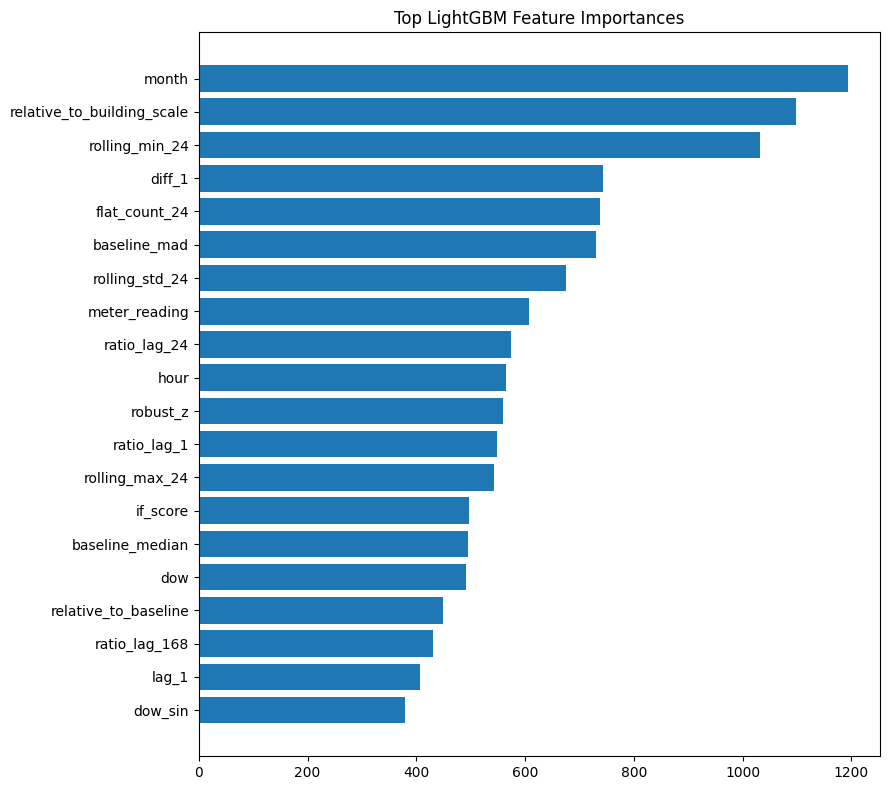

In [17]:
if HAVE_LGBM:
    importance = pd.DataFrame({
        "feature": MODEL_FEATURES_IF,
        "importance": clf_if.feature_importances_,
    }).sort_values("importance", ascending=False)

    display(importance.head(25))

    importance.to_csv(
        REPORTS / "feature_importance.csv",
        index=False,
    )

    fig, ax = plt.subplots(figsize=(9, 8))
    top_imp = importance.head(20).sort_values("importance")
    ax.barh(top_imp["feature"], top_imp["importance"])
    ax.set_title("Top LightGBM Feature Importances")
    fig.tight_layout()
    fig.savefig(
        ASSETS / "feature_importance.png",
        dpi=160,
        bbox_inches="tight",
    )
    plt.show()
    plt.close(fig)
else:
    print("Feature importance skipped for fallback HistGradientBoostingClassifier.")

## 6. Select final temporal model

In [18]:
# Final export selection uses VALIDATION PR-AUC only.
# Test metrics are reported for benchmarking but are not used to choose the exported model.

val_pr_base = safe_pr_auc(
    y_val.to_numpy(),
    lgb_val_scores,
)

val_pr_if = safe_pr_auc(
    y_val.to_numpy(),
    lgb_if_val_scores,
)

candidate_rows = [
    {
        "name": "GradientBoosting",
        "validation_pr_auc": val_pr_base,
        "model": clf,
        "features": MODEL_FEATURES,
        "threshold": lgb_threshold,
    },
    {
        "name": "GradientBoosting+IF",
        "validation_pr_auc": val_pr_if,
        "model": clf_if,
        "features": MODEL_FEATURES_IF,
        "threshold": lgb_if_threshold,
    },
]

best_candidate = max(
    candidate_rows,
    key=lambda x: x["validation_pr_auc"],
)

print("Best temporal model by VALIDATION PR-AUC:", best_candidate["name"])
print("Validation PR-AUC:", best_candidate["validation_pr_auc"])
print("Frozen threshold:", best_candidate["threshold"])


Best temporal model by VALIDATION PR-AUC: GradientBoosting+IF
Validation PR-AUC: 0.7364465234196856
Frozen threshold: 0.4106362430421004


## 7. Export model bundle

For operational inference, the app should receive enough history to compute the causal lags/rolling features.

Ground-truth `anomaly` must **not** be required by the app.

In [19]:
joblib.dump(
    {
        "model": best_candidate["model"],
        "model_name": best_candidate["name"],
        "feature_columns": best_candidate["features"],
        "threshold": best_candidate["threshold"],
        "baseline_tables": baseline_t,
        "if_model": if_model if "IF" in best_candidate["name"] else None,
        "if_scaler": if_scaler if "IF" in best_candidate["name"] else None,
        "if_features": IF_FEATURES if "IF" in best_candidate["name"] else None,
        "dataset_note": "LEAD building smart-meter benchmark; not real street-light telemetry.",
    },
    MODELS / "streetlight_anomaly_v6_bundle.joblib",
)

summary = {
    "project": "StreetLight Anomaly",
    "progress": "4%",
    "dataset": "LEAD — Large-scale Energy Anomaly Detection",
    "dataset_note": "Building smart-meter benchmark; not real street-light telemetry.",
    "primary_model": best_candidate["name"],
    "temporal_comparison": temporal_comparison.to_dict(orient="records"),
    "grouped_comparison": grouped_comparison.to_dict(orient="records"),
    "methodology": {
        "causal_features": True,
        "temporal_purge_gap_days": 7,
        "building_grouped_holdout": True,
        "validation_threshold_metric": "F2",
        "primary_ranking_metric": "PR-AUC",
        "operational_metrics": [
            "precision_at_k",
            "recall_at_k",
            "lift_vs_random",
            "event_recall",
            "false_alerts_per_building_week",
        ],
    },
    "limitations": [
        "LEAD is not street-light telemetry.",
        "Results are historical benchmark results, not production deployment claims.",
        "Building-grouped evaluation tests unseen-building generalization and is expected to be harder.",
        "Human verification remains required for any operational alert.",
    ],
}

(REPORTS / "final_summary.json").write_text(
    json.dumps(summary, indent=2, default=str),
    encoding="utf-8",
)

print(json.dumps(summary, indent=2, default=str)[:5000])

{
  "project": "StreetLight Anomaly",
  "progress": "4%",
  "dataset": "LEAD \u2014 Large-scale Energy Anomaly Detection",
  "dataset_note": "Building smart-meter benchmark; not real street-light telemetry.",
  "primary_model": "GradientBoosting+IF",
  "temporal_comparison": [
    {
      "model": "RobustZ",
      "rows": 256913,
      "base_rate": 0.02020139113240669,
      "predicted_rate": 0.08610307769556232,
      "accuracy": 0.9113201745337915,
      "precision": 0.10234618688124407,
      "recall": 0.43622350674373794,
      "f1": 0.1657940024166087,
      "roc_auc": 0.7467868973049305,
      "pr_auc": 0.08308529885186475,
      "threshold": 3.751419120246222,
      "total_events": 650,
      "detected_events": 274,
      "event_recall": 0.42153846153846153,
      "false_alert_points": 19857,
      "false_alerts_per_building_week": 12.728700449857488
    },
    {
      "model": "IsolationForest",
      "rows": 256913,
      "base_rate": 0.02020139113240669,
      "predicted_rate

## 8. ZIP outputs

In [20]:
ZIP_PATH = Path("/kaggle/working/streetlight_anomaly_v6_outputs.zip")

if ZIP_PATH.exists():
    ZIP_PATH.unlink()

with zipfile.ZipFile(ZIP_PATH, "w", zipfile.ZIP_DEFLATED) as zf:
    for directory in [REPORTS, MODELS, ASSETS]:
        for fp in directory.rglob("*"):
            if fp.is_file():
                zf.write(fp, fp.relative_to(WORK))

print("=" * 80)
print("DONE")
print("=" * 80)
print("ZIP:", ZIP_PATH)
print("ZIP MB:", round(ZIP_PATH.stat().st_size / 1024**2, 2))

DONE
ZIP: /kaggle/working/streetlight_anomaly_v6_outputs.zip
ZIP MB: 4.87


# Expected output

```text
/kaggle/working/streetlight_anomaly_v6_outputs.zip
```

Main files:

```text
models/
  streetlight_anomaly_v6_bundle.joblib

reports/
  temporal_model_comparison.csv
  temporal_topk_comparison.csv
  grouped_model_comparison.csv
  grouped_topk_comparison.csv
  feature_importance.csv
  final_summary.json

assets/
  feature_importance.png
```

## What to inspect first after Run All

```text
1. temporal_model_comparison.csv
2. temporal_topk_comparison.csv
3. grouped_model_comparison.csv
4. grouped_topk_comparison.csv
```

The main portfolio decision should be based on **PR-AUC + Recall@Top-5% + Lift@Top-5% + event recall**, not accuracy.